### Comparación final de modelos - Credit Risk Score

Este notebook resume la comparación final entre dos enfoques de modelos:

* 1.- Regresión logística con sckikit-learn
* 2.- Red neuronal MLP con PyTorch

El objetivo es evaluar desempeño predictivo, interpretabilidad y utilidad  de negocio para un problema de clasificación binaria de riesgo crediticio.

In [ ]:
# bibliotecas

import sys
from pathlib import Path
from dataclasses import asdict

import matplotlib.pyplot as plt
import pandas as pd
import torch

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.credit_risk.data.loader import load_raw_data
from src.credit_risk.data.preprocessing import preprocess_credit_data
from src.credit_risk.data.schema import validate_credit_risk_data
from src.credit_risk.features.engineering import build_features
from src.credit_risk.models.sklearn_model import SklearnCreditModel
from src.credit_risk.models.torch_dataset import CreditRiskTorchDataset
from src.credit_risk.models.torch_model import (
    CreditRiskMLP,
    get_torch_device,
    train_torch_model,
    predict_torch_model,
)
from src.credit_risk.evaluation.metrics import summarize_metrics
from src.credit_risk.evaluation.results import ModelMetrics


# reproductibilidad
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# uso de gpu
device = get_torch_device()
print(f"Using device: {device}")

device(type='cpu')

In [42]:
# Carga de datos

paths_config = PROJECT_ROOT / "configs" / "paths.yaml"
model_config = PROJECT_ROOT / "configs" / "model.yaml"

df = load_raw_data(paths_config)
df = preprocess_credit_data(df, model_config)
df = build_features(df)
df = validate_credit_risk_data(df)

df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,target,debt_income_ratio,credit_maturity,employment_years,age_group
0,1.0,22,59000,RENT,123.0,PERSONAL,C,35000.0,16.02,10,1.0,3,DEFAULT,1,0.593220,0.136364,10.250000,18-25
1,2.0,21,9600,OWN,5.0,EDUCATION,A,1000.0,11.14,1,1.0,2,NO DEFAULT,0,0.104167,0.095238,0.416667,18-25
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,0.0,3,DEFAULT,1,0.572917,0.120000,0.083333,18-25
3,4.0,23,65500,RENT,4.0,MEDICAL,B,35000.0,15.23,10,0.0,2,DEFAULT,1,0.534351,0.086957,0.333333,18-25
4,5.0,24,54400,RENT,8.0,MEDICAL,B,35000.0,14.27,10,1.0,4,DEFAULT,1,0.643382,0.166667,0.666667,18-25


In [43]:
# Revisando dimensiones y distribución de la variable target
df.shape, df["target"].value_counts(normalize=True)

((32583, 18),
 target
 0    0.790105
 1    0.209895
 Name: proportion, dtype: float64)

In [44]:
# split

X = df.drop(columns=["Current_loan_status", "target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((26066, 16), (6517, 16))

### Modelo sklearn - Regresión logística con scikit-learn

* La regresión logística se utiliza como baseline interpretable.
* El modelo incorpora un pipeline con preprocesamiento integrado para variables numéricas y categóricas.

In [45]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()

sk_model = SklearnCreditModel(
    model_config_path=model_config,
    num_cols=num_cols,
    cat_cols=cat_cols,
)

sk_model.train(X_train, y_train)

y_pred_sk = sk_model.predict(X_test)
y_proba_sk = sk_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_sk))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_sk))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      5149
           1       0.90      0.78      0.84      1368

    accuracy                           0.94      6517
   macro avg       0.92      0.88      0.90      6517
weighted avg       0.94      0.94      0.94      6517

ROC-AUC: 0.9668424800591496


In [46]:
sklearn_results = summarize_metrics(y_test, y_pred_sk, y_proba_sk)

sklearn_metrics_obj = ModelMetrics(
    model_name="Logistic Regression",
    precision_default=sklearn_results["precision_default"],
    recall_default=sklearn_results["recall_default"],
    f1_default=sklearn_results["f1_default"],
    roc_auc=sklearn_results["roc_auc"],
    notes="Modelo base interpretable y estable.",
)

sklearn_metrics_obj

ModelMetrics(model_name='Logistic Regression', precision_default=0.9037162162162162, recall_default=0.7821637426900585, f1_default=0.8385579937304075, roc_auc=0.9668424800591496, notes='Modelo base interpretable y estable.')

#### Matriz de confusión sklearn

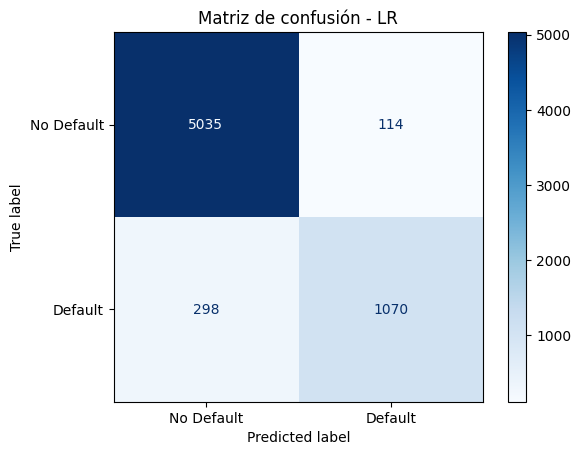

In [47]:
cm_sk = confusion_matrix(y_test, y_pred_sk)

ConfusionMatrixDisplay(
    confusion_matrix=cm_sk,
    display_labels=["No Default", "Default"],
).plot(cmap="Blues")

plt.title("Matriz de confusión - LR")
plt.show();

#### Curva ROC sklearn

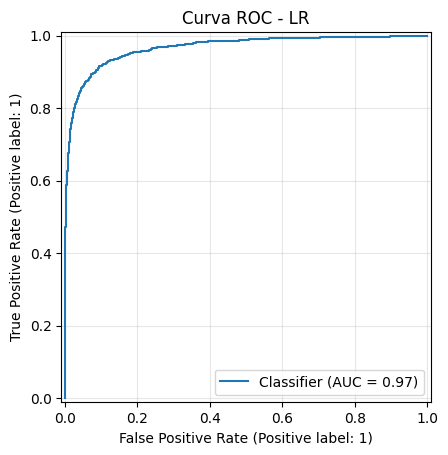

In [48]:
RocCurveDisplay.from_predictions(y_test, y_proba_sk)
plt.title("Curva ROC - LR")
plt.grid(alpha=0.3)
plt.show();

## Modelo con pytorch

* El segundo modelo es una red neuronal multicapa implementada en pytorch
* Este enfoque busca capturar relaciones no lineales entre las variables financieras y el deafult

In [49]:
X_train_torch = pd.get_dummies(X_train, drop_first=True)
X_test_torch = pd.get_dummies(X_test, drop_first=True)
X_test_torch = X_test_torch.reindex(columns=X_train_torch.columns, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_torch)
X_test_scaled = scaler.transform(X_test_torch)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = CreditRiskTorchDataset(X_train_tensor, y_train_tensor)
test_dataset = CreditRiskTorchDataset(X_test_tensor, y_test_tensor)

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    generator=generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
)

In [ ]:
input_dim = X_train_tensor.shape[1]
torch_model = CreditRiskMLP(input_dim)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.001)

train_losses = train_torch_model(
    model=torch_model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=100,
    patience=10,
    min_delta=0.0001,
    device=device,
)

y_true_torch, probs_torch, y_pred_torch = predict_torch_model(
    model=torch_model,
    data_loader=test_loader,
    threshold=0.5,
    device=device,
)

Epoch [1/50] - Loss: 0.2542
Epoch [2/50] - Loss: 0.1476
Epoch [3/50] - Loss: 0.1374
Epoch [4/50] - Loss: 0.1296
Epoch [5/50] - Loss: 0.1254
Epoch [6/50] - Loss: 0.1217
Epoch [7/50] - Loss: 0.1195
Epoch [8/50] - Loss: 0.1165
Epoch [9/50] - Loss: 0.1163
Epoch [10/50] - Loss: 0.1136
Epoch [11/50] - Loss: 0.1108
Epoch [12/50] - Loss: 0.1093
Epoch [13/50] - Loss: 0.1087
Epoch [14/50] - Loss: 0.1085
Epoch [15/50] - Loss: 0.1093
Epoch [16/50] - Loss: 0.1063
Epoch [17/50] - Loss: 0.1057
Epoch [18/50] - Loss: 0.1038
Epoch [19/50] - Loss: 0.1038
Epoch [20/50] - Loss: 0.1020
Epoch [21/50] - Loss: 0.1033
Epoch [22/50] - Loss: 0.1017
Epoch [23/50] - Loss: 0.1008
Epoch [24/50] - Loss: 0.1013
Epoch [25/50] - Loss: 0.1001
Epoch [26/50] - Loss: 0.0972
Epoch [27/50] - Loss: 0.0982
Epoch [28/50] - Loss: 0.0958
Epoch [29/50] - Loss: 0.0962
Epoch [30/50] - Loss: 0.0984
Epoch [31/50] - Loss: 0.0958
Epoch [32/50] - Loss: 0.0965
Epoch [33/50] - Loss: 0.0937
Epoch [34/50] - Loss: 0.0935
Epoch [35/50] - Loss: 0

#### Curva de pérdida

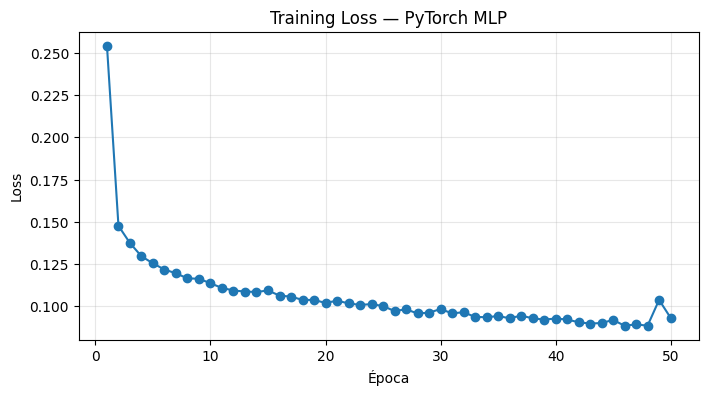

In [51]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker="o")
plt.title("Training Loss — PyTorch MLP")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show();

#### Evaluación pytorch

In [ ]:
y_true_torch, probs_torch, y_pred_torch = predict_torch_model(
    torch_model,
    test_loader,
)

y_true_np = y_true_torch.cpu().numpy()
probs_np = probs_torch.cpu().numpy()
y_pred_np = y_pred_torch.cpu().numpy()

print(classification_report(y_true_np, y_pred_np))
print("ROC-AUC:", roc_auc_score(y_true_np, probs_np))

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98      5149
         1.0       0.97      0.86      0.92      1368

    accuracy                           0.97      6517
   macro avg       0.97      0.93      0.95      6517
weighted avg       0.97      0.97      0.97      6517

ROC-AUC: 0.987144284531488


In [53]:
torch_results = summarize_metrics(y_true_np, y_pred_np, probs_np)

torch_metrics_obj = ModelMetrics(
    model_name="PyTorch MLP",
    precision_default=torch_results["precision_default"],
    recall_default=torch_results["recall_default"],
    f1_default=torch_results["f1_default"],
    roc_auc=torch_results["roc_auc"],
    notes="Modelo más flexible con mayor capacidad predictiva.",
)

torch_metrics_obj

ModelMetrics(model_name='PyTorch MLP', precision_default=0.9736408566721582, recall_default=0.8640350877192983, f1_default=0.9155693261037955, roc_auc=0.987144284531488, notes='Modelo más flexible con mayor capacidad predictiva.')

#### Matriz de confusión con pytorch

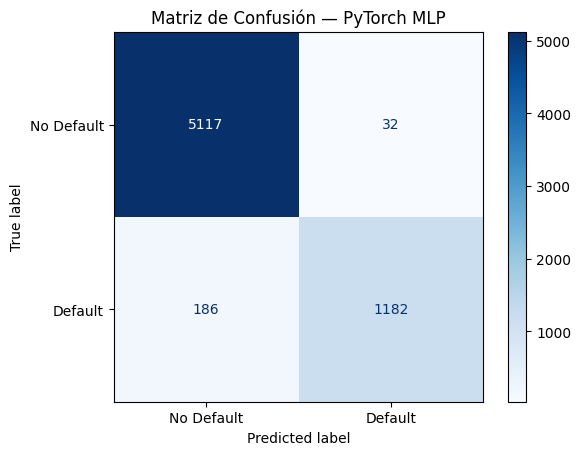

In [54]:
cm_torch = confusion_matrix(y_true_np, y_pred_np)

ConfusionMatrixDisplay(
    confusion_matrix=cm_torch,
    display_labels=["No Default", "Default"],
).plot(cmap="Blues")

plt.title("Matriz de Confusión — PyTorch MLP")
plt.show();

#### Curva ROC pytorch

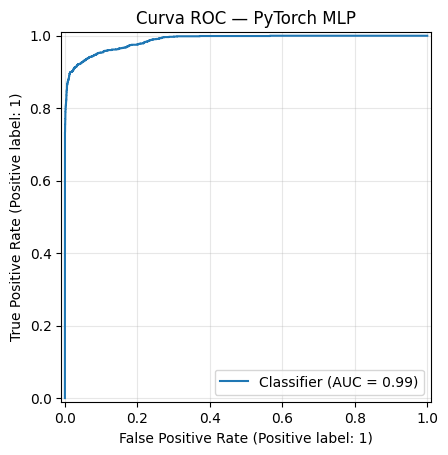

In [55]:
RocCurveDisplay.from_predictions(y_true_np, probs_np)
plt.title("Curva ROC — PyTorch MLP")
plt.grid(alpha=0.3)
plt.show();

#### Comparación final

In [56]:
comparison_df = pd.DataFrame(
    [
        asdict(sklearn_metrics_obj),
        asdict(torch_metrics_obj),
    ]
)

comparison_df = comparison_df[
    [
        "model_name",
        "precision_default",
        "recall_default",
        "f1_default",
        "roc_auc",
        "notes",
    ]
]

comparison_df.round(4)

,model_name,precision_default,recall_default,f1_default,roc_auc,notes
0,Logistic Regression,0.9037,0.7822,0.8386,0.9668,Modelo base interpretable y estable.
1,PyTorch MLP,0.9736,0.8640,0.9156,0.9871,Modelo más flexible con mayor capacidad predic...


#### Gráfica comparativa

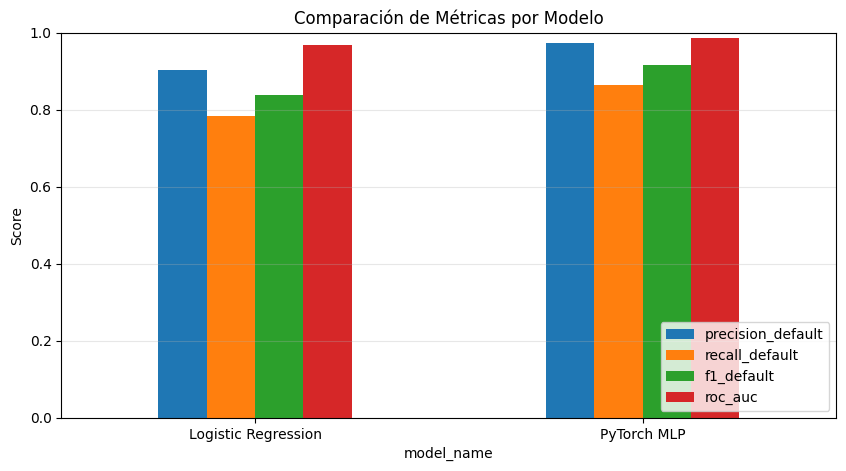

In [57]:
plot_df = comparison_df.set_index("model_name")[
    ["precision_default", "recall_default", "f1_default", "roc_auc"]
]

ax = plot_df.plot(kind="bar", figsize=(10, 5), rot=0)
plt.title("Comparación de Métricas por Modelo")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.show();

## Conclusión

La regresión logística funciona como un baseline sólido, interpretable y estable.  
Su principal ventaja es la facilidad de explicación, lo cual puede ser relevante en contextos financieros o regulatorios.

El modelo MLP implementado en PyTorch muestra un mejor desempeño predictivo, especialmente en métricas como F1-score y ROC-AUC. Esto sugiere que la red neuronal captura relaciones no lineales que el modelo lineal no aprovecha completamente.

Desde una perspectiva de negocio, la elección del modelo depende del objetivo:

- Si se prioriza explicabilidad, la regresión logística es una alternativa defendible.
- Si se prioriza desempeño predictivo, el MLP de PyTorch ofrece mejores resultados.

En conjunto, ambos modelos permiten construir una solución robusta para scoring de riesgo crediticio.